# Linking me-properties to molecular identity
Depth-independent morphoelectric groups reflect the molecular identity of cortical inhibitory neurons.

In [1]:
# Load project-specific library
import decoupling

# Load other required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from matplotlib.patches import Rectangle
from sklearn.metrics.cluster import contingency_matrix

# Define global matplotlib settings
plt.rcParams.update({
    "font.family": "Arial",
})

# Set random seed
seed = decoupling.set_seed(0)

# Set path to data
data_path = "../data/"

Random seed 0 has been set.


In [2]:
# Read rat bc molecular profiles
bc_molecular_composition = pd.read_csv(
    os.path.join(data_path, "rat_bc/processed/bc_molecular_composition.csv"), 
)

# Set layer borders in an average cortical column
layer_labels = pd.DataFrame({
    "depth": [0.15, 0.551, 0.847, 1.342, 1.887], 
    "label": ["L1", "L2/3", "L4", "L5", "L6"],
})

# Read rat bc metadata
bc_metadata = pd.read_csv(
    os.path.join(data_path, "rat_bc/bc_metadata.csv"), 
    index_col="neuron_id",
)

# Read rat bc features
bc_features = pd.read_csv(
    os.path.join(data_path, "rat_bc/processed/bc_consolidated_features.csv"), 
    index_col="neuron_id",
)

# Read mouse v1 metadata
v1_metadata = pd.read_csv(
    os.path.join(data_path, "mouse_v1/v1_patchseq_metadata.csv"), 
    index_col="neuron_id",
)

# Read mouse v1 features
v1_features = pd.read_csv(
    os.path.join(data_path, "mouse_v1/processed/v1_patchseq_features.csv"), 
    index_col="neuron_id",
)

## Comparison of predicted and empirical depth profiles
* Quantification of the distributions of PV+, Sst+ and Vip+ inhibitory neurons across cortical depth.
* Calculation of the depth-distributions of Groups I-IIIa/b from the sampled inhibitory neurons.

In [3]:
# Set molecular marker labels
marker_labels = ["PV", "Sst", "Vip", "-/-/-"]

# Get predicted molecular identities
predicted_markers = (
    bc_metadata["pred_mol_id"]
    .map({
        "PV+": marker_labels[0],
        "SST+": marker_labels[1],
        "VIP+": marker_labels[2],
        "PV-/SST-/VIP-": marker_labels[3],
    })
    .values
)

# Calculate depth profiles using molecular marker predictions
predicted_profiles = decoupling.compute_molecular_profiles(
    soma_depth=bc_metadata["normalized_soma_depth"]
        * layer_labels["depth"].max(),
    markers=predicted_markers,
)

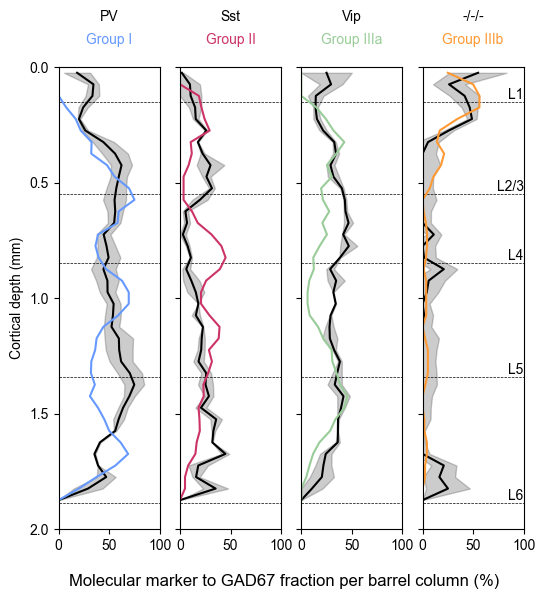

In [4]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(6, 6), sharey=True)

marker_colors = ["#6699FF", "#CC3366", "#99CC99", "#FF9933"]
group_labels = ["Group I", "Group II", "Group IIIa", "Group IIIb"]

for (ax, marker, color, group) in zip(
    axs, marker_labels, marker_colors, group_labels
):
    # ---------------------------------------------------------------------
    # Plot cortical layer boundaries
    # ---------------------------------------------------------------------
    for _, layer in layer_labels.iterrows():
        ax.axhline(
            y=layer["depth"],
            linestyle="--",
            linewidth=0.5,
            color="black",
        )
        if marker == marker_labels[-1]:
            ax.text(
                x=100,                
                y=layer["depth"],
                s=layer["label"],
                va="bottom",
                ha="right",
            )

    # ---------------------------------------------------------------------
    # Plot the depth-distribution of molecular markers in a cortical column
    # ---------------------------------------------------------------------
    molecular_profile = bc_molecular_composition[
        bc_molecular_composition["marker"]==marker
    ]
    ax.fill_betweenx(
        x1=molecular_profile["fraction"] - molecular_profile["sem"], 
        x2=molecular_profile["fraction"] + molecular_profile["sem"], 
        y=molecular_profile["depth"],
        color="black", 
        alpha=0.2,
    )
    ax.plot(
        molecular_profile["fraction"], 
        molecular_profile["depth"], 
        color="black", 
    )

    # ---------------------------------------------------------------------
    # Plot predicted molecular identities of the sampled inhibitory neurons
    # ---------------------------------------------------------------------
    predicted_profile = predicted_profiles[
        predicted_profiles["marker"]==marker
    ]
    ax.plot(
        predicted_profile["fraction"], 
        predicted_profile["depth"],  
        color=color,
    )

    # ---------------------------------------------------------------------
    # Axis annotations and formatting
    # ---------------------------------------------------------------------
    ax.text(
        0.5, 1.10, 
        marker,  
        ha="center", 
        color="black",
        transform=ax.transAxes,
    )
    ax.text(
        0.5, 1.05, 
        group,  
        ha="center", 
        color=color, 
        transform=ax.transAxes,
    )
    
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 150, 50))
    
    ax.set_ylim(2, 0)
    ax.set_yticks(np.arange(0, 2.5, 0.5))
    
    if marker == marker_labels[0]:
        ax.set_ylabel("Cortical depth (mm)")

fig.supxlabel("Molecular marker to GAD67 fraction per barrel column (%)")

plt.show()

## Shared depth-specific relationships across species
* Laminar distribution of me-features that separated inhibitory neurons from rat barrel cortex into the depth-independent Groups I-IIIa/b.
* Repetition of analysis in mouse visual cortex. 

In [5]:
# Select features for analysis
features = [
    "axon_vertical_extent",
    "dendrite_vertical_extent", 
    "spike_frequency",
    "spike_frequency_adaptation",
]

# Prepare rat bc features 
bc_features = (
    bc_features[features]
    .dropna()
)

# Prepare mouse v1 features
v1_features = (
    v1_features[features]
    .dropna()
)

# Set rat bc ticks for plot
bc_ticks = [
    [  0, 0.8, 1.6, 2.4], # axon ext. in mm
    [  0, 0.4, 0.8, 1.2], # den. ext. in mm
    [  0,  90, 180, 270], # spiking freq. in Hz
    [-40,  20,  80, 140], # adaptation in %
]

# Set mouse v1 ticks for plot
v1_ticks = [
    [  0, 0.4, 0.8, 1.2], # axon ext. in mm
    [  0, 0.3, 0.6, 0.9], # den. ext. in mm
    [  0,  90, 180, 270], # spiking freq. in Hz
    [-40,  20,  80, 140], # adaptation in %
]

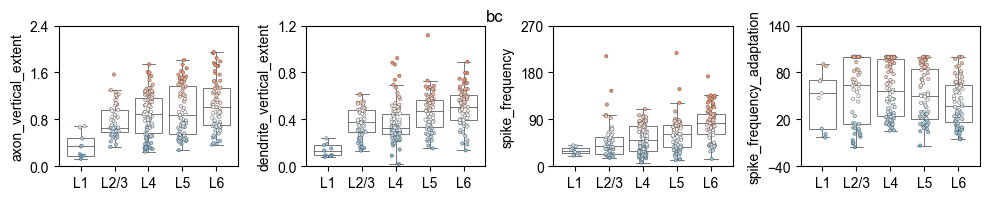

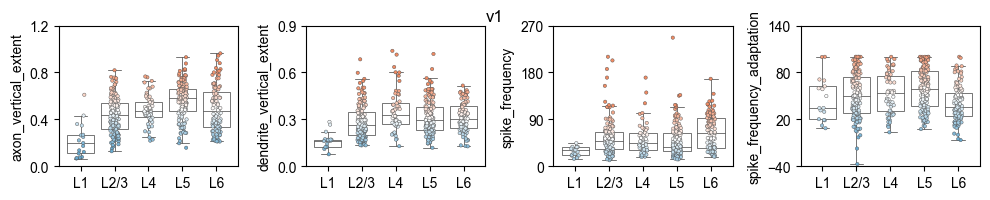

In [6]:
for (feats, meta, ticks, name) in zip(
    [bc_features, v1_features],
    [bc_metadata, v1_metadata],
    [bc_ticks, v1_ticks],
    ["bc", "v1"],
):  
    # Add layer labels to features
    X = (
        feats.copy()
        .assign(layer=meta["layer"])  
        .sort_values(by="layer")
    )

    # Plot morphoelectric features by cortical layer
    fig, axs = decoupling.plot_features_by_layer(
        X=X, ticks=ticks,
    )
    fig.suptitle(name)
    
    plt.show()


## Assessing met-clusters by depth-independent morphoelectric variations
As in rat barrel cortex, morphoelectric features of transcriptomic-validated morphoelectric class assignments (met-clusters) in mouse V1 are categorized by Groups I-IIIa/b.

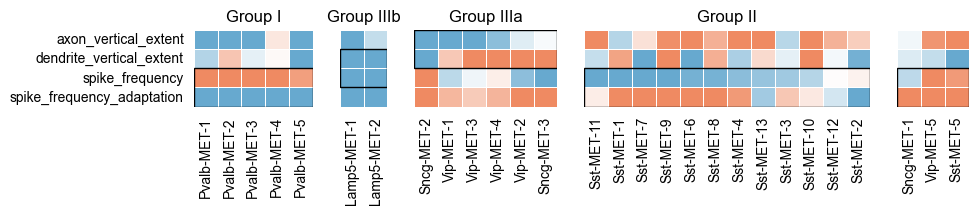

In [7]:
# Z-score mouse v1 features
zscored_v1_features = v1_features.apply(zscore)

# Calculate cluster-averaged features
cluster_means = (
    zscored_v1_features
    .groupby([v1_metadata.loc[v1_features.index, "met_cluster"]])
    .mean(numeric_only=True) 
    .transpose()
)

# Sort met-clusters
cluster_means = cluster_means[[
    # Group I:
    "Pvalb-MET-1", "Pvalb-MET-2", "Pvalb-MET-3", "Pvalb-MET-4", "Pvalb-MET-5", 
    # Group IIIb:
    "Lamp5-MET-1", "Lamp5-MET-2",
    # Group IIIa:
    "Sncg-MET-2", "Vip-MET-1", "Vip-MET-3", "Vip-MET-4", "Vip-MET-2", "Sncg-MET-3",
    # Group II:
    "Sst-MET-11", "Sst-MET-1", "Sst-MET-7", "Sst-MET-9", "Sst-MET-6", "Sst-MET-8", 
    "Sst-MET-4", "Sst-MET-13", "Sst-MET-3", "Sst-MET-10", "Sst-MET-12", "Sst-MET-2",
    # rest:
    "Sncg-MET-1", "Vip-MET-5", "Sst-MET-5",
]]

# Set group labels
group_labels = ["Group I", "Group IIIb", "Group IIIa", "Group II", ""]

# Set number of met-cluster per group
n_classes_per_group = [5, 2, 6, 12, 3]

# Define an index to slice features matrix
idx = np.cumsum([0] + n_classes_per_group)

# Set colormap
cmap = decoupling.utils.default_colormap()

# Plot met-clusters
fig, axs = plt.subplots(
    nrows=1, ncols=5, figsize=(10,1), 
    gridspec_kw={"width_ratios": n_classes_per_group},
)

for i, j in zip(range(len(n_classes_per_group)), [2, 1, 0, 2, 2]):
    
    # Plot heatmap
    sns.heatmap(
        cluster_means.iloc[:,idx[i]:idx[i+1]], 
        vmin=-0.5, 
        vmax=0.5, 
        linewidth=0.5, 
        cmap=cmap, 
        cbar=False, 
        yticklabels=(i == 0), 
        ax=axs[i],
    )

    # Add annotations
    axs[i].add_patch(
        Rectangle(
            xy=(0, j), 
            width=n_classes_per_group[i], 
            height=2, 
            fill=False, 
            edgecolor="black", 
            lw=1,
        )
    )

    # Axis formatting
    axs[i].set_xlabel("")
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
    axs[i].tick_params(left=False, bottom=False)
    axs[i].set_title(group_labels[i])

plt.show()


A schema for mouse V1 is defined based on the same criteria that was identified from rat barrel cortex.

In [8]:
schema = {
        group_labels[0]: {
            "spike_frequency": (">", 0.15),
            "spike_frequency_adaptation": ("<", -0.35),
            "_logic": "and",
        },
        group_labels[1]: {
            "spike_frequency": (
                "<linear", 
                "dendrite_vertical_extent", 
                (-1, -3/2),
            ),
        },
        group_labels[2]: {
            "axon_vertical_extent": ("<", -0.45),
            "dendrite_vertical_extent": (">", 0.85),
            "_logic": "or",
        },
        group_labels[3]: {
            "spike_frequency": (
                "<linear", 
                "spike_frequency_adaptation", 
                (-1/3, 0.05),
            ),
        }
    }

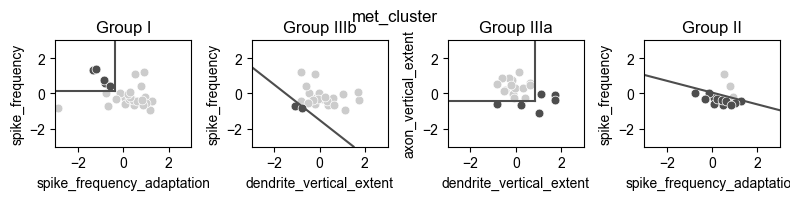

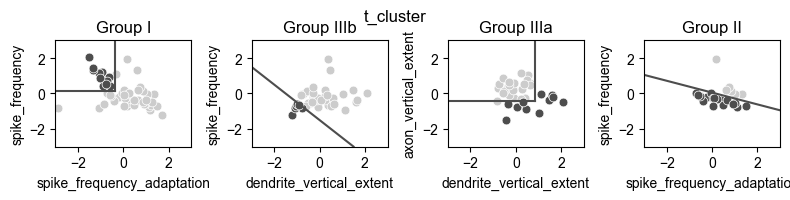

In [9]:
for i in ["met_cluster", "t_cluster"]:

    # Average features by cluster
    cluster_means = (
        zscored_v1_features
        .groupby(v1_metadata.loc[v1_features.index, i])
        .mean(numeric_only=True) 
    )

    # Plot decoupling schema
    fig, axs = decoupling.plot_decoupling_schema(
        cluster_means=cluster_means, 
        schema=schema,
    )
    fig.suptitle(i)

    plt.show()


## Depth-independent morphoelectric variations reveal the molecular identity of inhibitory neurons
* Assignment of inhibitory neurons from mouse V1 to Groups I-IIIa/b based on their morphoelectric features.
* Comparison of predicted and actual molecular identity.

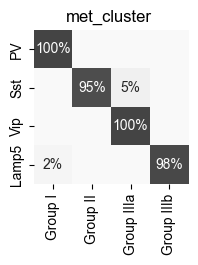

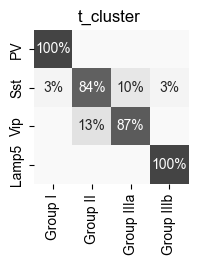

In [10]:
# Set decoupling model for mouse v1
model = decoupling.Decoupling(
    schema=schema,
)

# Update labels
mapping = {
    "Pvalb": "PV",
    "Sncg": "Vip",
    "Serpinf1": "Vip",
}

# Get molecular identity
v1_mol_id = (
    v1_metadata.loc[v1_features.index, "t_cluster"]
    .astype(str).str.split().str[0]
    .replace(mapping)
    .tolist()
)

# Set colormap
cmap = sns.color_palette(
    "blend:#f9f9f9,#444444", 
    as_cmap=True,
)

for i in ["met_cluster", "t_cluster"]:

    # Predict molecular identity
    predicted_labels = model.fit_predict(
        features = zscored_v1_features,
        local_grouping = v1_metadata.loc[v1_features.index, i],
    )

    # Calculate contingency matrix
    labels_x = predicted_labels
    labels_y = v1_mol_id
    
    original_y_order = list(np.unique(labels_y))
    original_x_order = list(np.unique(labels_x))

    desired_y_order = ["PV", "Sst", "Vip", "Lamp5"]
    desired_x_order = list(np.unique(labels_x))

    cont = contingency_matrix(labels_y, labels_x)
    cont = np.round(100 * cont / cont.sum(axis=1, keepdims=True))
    cont = cont[np.ix_(
        [original_y_order.index(y) for y in desired_y_order], 
        [original_x_order.index(x) for x in desired_x_order],
    )]

    # Plot contingency matrix
    fig, ax = plt.subplots(figsize=(2, 2))
    fig.suptitle(i)
    sns.heatmap(
        cont.astype(int),
        cmap=cmap,
        annot=True,
        fmt="d",
        cbar=False,
        ax=ax,        
        xticklabels=desired_x_order,
        yticklabels=desired_y_order,
    )

    # Add annotations
    for text in ax.texts:
        value = int(text.get_text())
        if value > 0:
            text.set_text(f"{value}%")
            text.set_ha("center")
            text.set_va("center")
        else:
            text.set_text("")
    
    plt.show()
